# Experiment 2: Synthetic Sparse-Coding Transition and Baselines

Proposal target: train VG-SAE on `x = D* z* + noise`, sweep `lambda`, compare against L1-ReLU, TopK, a deterministic sigmoid-gated SAE, and ablate the VG variance term.

Logged quantities: MSE, active density, gate entropy, `V_eff`, susceptibility, interference, dead latents, decoder recovery cosine, support precision/recall, and amplitude shrinkage.


In [2]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / "outputs" / ".matplotlib"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))
DEVICE = torch.device("mps")
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "notebooks"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
from src.sae_data import SyntheticSparseCodingConfig, make_synthetic_sparse_coding
from src.sae_evaluate import (
    amplitude_shrinkage,
    decoder_recovery_cosine,
    support_precision_recall,
    susceptibility,
    vg_sae_observables,
)
from src.sae_model import (
    GatedSAE, GatedSAEConfig,
    L1ReLUSAE, L1SAEConfig,
    TopKSAE, TopKSAEConfig,
    VGSAEConfig, VariationalGarroteSAE,
)
from src.sae_train import fit_sae

input_dim = 16
widths = [32, 64]
lambdas = [0.0, 0.5, 1.0, 2.0, 3.0]
train_steps = 250
batch_size = 128
data_cfg = dict(
    input_dim=input_dim,
    n_samples=512,
    support_density=0.06,
    coherence=0.1,
    noise_std=0.03,
    frequency_skew=0.0,
    seed=1,
)


In [4]:
def decoder_weight(model):
    return model.W_dec.T if hasattr(model, "W_dec") else model.decoder.weight


def run_vg(data, width, lambda_sparsity, use_variance_term=True, label="vg"):
    model = VariationalGarroteSAE(
        VGSAEConfig(
            input_dim=data.x.shape[1],
            n_latents=width,
            lambda_sparsity=lambda_sparsity,
            beta=1.0,
            use_variance_term=use_variance_term,
        )
    )
    fit_sae(model, data.x, max_steps=train_steps, batch_size=batch_size, lr=3e-3, history_every=100, seed=0)
    obs = vg_sae_observables(model, data.x)
    precision, recall = support_precision_recall(model, data.x, data.support, data.dictionary)
    return {
        "model": label,
        "width": width,
        "lambda": lambda_sparsity,
        "mse": obs.mse,
        "rho": obs.rho,
        "entropy": obs.entropy,
        "v_eff": obs.v_eff,
        "dead_fraction": obs.dead_fraction,
        "interference_energy": obs.interference_energy,
        "variance_energy": obs.variance_energy,
        "decoder_recovery_cosine": decoder_recovery_cosine(decoder_weight(model), data.dictionary),
        "support_precision": precision,
        "support_recall": recall,
        "amplitude_shrinkage": amplitude_shrinkage(model, data.x, data.z, data.dictionary),
    }

def run_baselines(data, width):
    k = max(1, round(data.support.mean().item() * width))
    baselines = [
        ("l1", L1ReLUSAE(L1SAEConfig(input_dim=data.x.shape[1], n_latents=width, l1_coefficient=1e-3))),
        ("topk", TopKSAE(TopKSAEConfig(d_in=data.x.shape[1], d_sae=width, k=k))),
        ("gated", GatedSAE(GatedSAEConfig(d_in=data.x.shape[1], d_sae=width, l1_coefficient=1e-3))),
    ]
    rows = []
    for name, model in baselines:
        result = fit_sae(model, data.x, max_steps=train_steps, batch_size=batch_size, lr=3e-3, history_every=100, seed=0)
        final = result.history[-1]
        rows.append({
            "model": name,
            "width": width,
            "lambda": np.nan,
            "mse": final["reconstruction_mse"],
            "rho": final["rho"],
            "entropy": np.nan,
            "v_eff": np.nan,
            "dead_fraction": np.nan,
            "interference_energy": np.nan,
            "variance_energy": np.nan,
            "decoder_recovery_cosine": decoder_recovery_cosine(decoder_weight(model), data.dictionary),
            "support_precision": np.nan,
            "support_recall": np.nan,
            "amplitude_shrinkage": np.nan,
        })
    return rows


In [5]:
rows = []
for width in widths:
    data = make_synthetic_sparse_coding(SyntheticSparseCodingConfig(n_features=width, **data_cfg), device=DEVICE)
    for lam in lambdas:
        rows.append(run_vg(data, width, lam, use_variance_term=True, label="vg"))
        # rows.append(run_vg(data, width, lam, use_variance_term=False, label="vg_no_variance"))
    rows.extend(run_baselines(data, width))

df = pd.DataFrame(rows)
# for model_name in ["vg", "vg_no_variance"]:
for model_name in ["vg",]:
    for width in widths:
        mask = (df["model"] == model_name) & (df["width"] == width)
        df.loc[mask, "susceptibility"] = susceptibility(
            df.loc[mask, "lambda"].to_numpy(dtype=float),
            df.loc[mask, "rho"].to_numpy(dtype=float),
        )
df.head()


,model,width,lambda,mse,rho,entropy,v_eff,dead_fraction,interference_energy,variance_energy,decoder_recovery_cosine,support_precision,support_recall,amplitude_shrinkage,susceptibility
0,vg,32,-1.0,0.051138,0.399640,0.560975,0.189990,0.0,5.593621,1.208116,0.624235,0.104340,0.442270,0.961467,0.060167
1,vg,32,0.0,0.053709,0.339474,0.586136,0.199517,0.0,3.938131,1.234842,0.650921,0.131534,0.300391,0.802095,0.082107
2,vg,32,1.0,0.078800,0.235427,0.534478,0.175476,0.0,1.904619,1.322640,0.657170,0.463855,0.075342,0.603551,0.109716
3,vg,32,2.0,0.108011,0.120042,0.359579,0.103401,0.0,0.564398,1.031280,0.672144,0.584906,0.030333,0.370080,0.084053
4,vg,32,3.0,0.160485,0.067320,0.240589,0.061649,0.0,0.210016,0.718877,0.651334,0.684211,0.012720,0.205653,0.052721


,model,width,lambda,mse,rho,entropy,v_eff,dead_fraction,interference_energy,variance_energy,decoder_recovery_cosine,support_precision,support_recall,amplitude_shrinkage,susceptibility
0,vg,32,-1.0,0.051138,0.399640,0.560975,0.189990,0.0,5.593621,1.208116,0.624235,0.104340,0.442270,0.961467,0.060167
1,vg,32,0.0,0.053709,0.339474,0.586136,0.199517,0.0,3.938131,1.234842,0.650921,0.131534,0.300391,0.802095,0.082107
2,vg,32,1.0,0.078800,0.235427,0.534478,0.175476,0.0,1.904619,1.322640,0.657170,0.463855,0.075342,0.603551,0.109716
3,vg,32,2.0,0.108011,0.120042,0.359579,0.103401,0.0,0.564398,1.031280,0.672144,0.584906,0.030333,0.370080,0.084053
4,vg,32,3.0,0.160485,0.067320,0.240589,0.061649,0.0,0.210016,0.718877,0.651334,0.684211,0.012720,0.205653,0.052721
5,l1,32,NaN,0.004065,0.761292,NaN,NaN,NaN,NaN,NaN,0.588921,NaN,NaN,NaN,NaN
6,topk,32,NaN,0.069771,0.062500,NaN,NaN,NaN,NaN,NaN,0.644772,NaN,NaN,NaN,NaN
7,gated,32,NaN,0.012666,0.219953,NaN,NaN,NaN,NaN,NaN,0.628153,NaN,NaN,NaN,NaN
8,vg,64,-1.0,0.066830,0.444270,0.554071,0.187802,0.0,31.892963,2.186426,0.629112,0.077693,0.478417,1.680416,0.082653
9,vg,64,0.0,0.066665,0.361616,0.597230,0.205077,0.0,19.370014,2.342701,0.647862,0.092650,0.278520,1.476890,0.102896


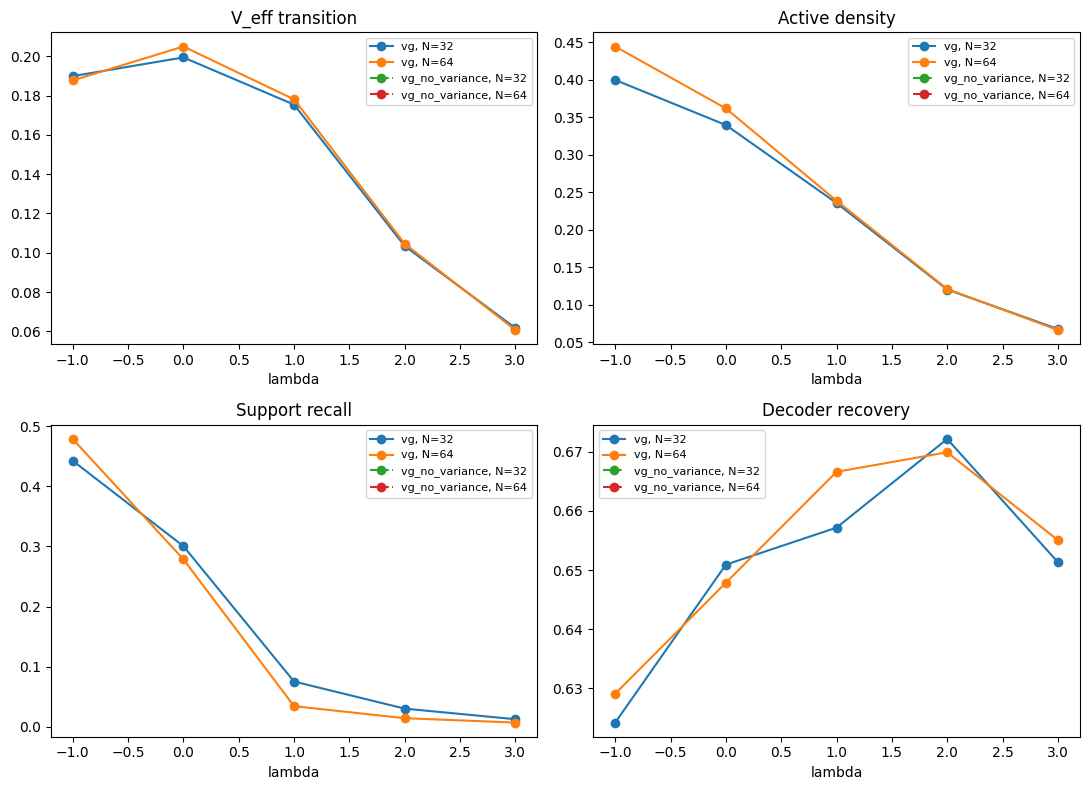

In [6]:
out = OUTPUT_DIR / "exp02_synthetic_sparse_coding"
out.mkdir(parents=True, exist_ok=True)
df.to_csv(out / "synthetic_sparse_coding_sweep.csv", index=False)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for model_name, style in [("vg", "-o"), ("vg_no_variance", "--o")]:
    for width in widths:
        sub = df[(df["model"] == model_name) & (df["width"] == width)].sort_values("lambda")
        axes[0, 0].plot(sub["lambda"], sub["v_eff"], style, label=f"{model_name}, N={width}")
        axes[0, 1].plot(sub["lambda"], sub["rho"], style, label=f"{model_name}, N={width}")
        axes[1, 0].plot(sub["lambda"], sub["support_recall"], style, label=f"{model_name}, N={width}")
        axes[1, 1].plot(sub["lambda"], sub["decoder_recovery_cosine"], style, label=f"{model_name}, N={width}")
axes[0, 0].set_title("V_eff transition")
axes[0, 1].set_title("Active density")
axes[1, 0].set_title("Support recall")
axes[1, 1].set_title("Decoder recovery")
for ax in axes.ravel():
    ax.set_xlabel("lambda")
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(out / "synthetic_sparse_coding_summary.png", dpi=160)
df


**Interpretation rule:** the variance-term ablation is the novelty defense. If `vg_no_variance` matches VG on uncertainty calibration and support recovery, the proposal’s central claim is weak and needs revision.


### Baselines vs selected VG checkpoints

,width,selection,model,lambda,mse,rho,decoder_recovery_cosine,support_precision,support_recall,amplitude_shrinkage,variance_energy
2,32,baseline,gated,nan,0.0127,0.220,0.628,nan,nan,nan,nan
0,32,baseline,l1,nan,0.0041,0.761,0.589,nan,nan,nan,nan
1,32,baseline,topk,nan,0.0698,0.062,0.645,nan,nan,nan,nan
5,32,best_vg_decoder_recovery,vg,2.0,0.1080,0.120,0.672,0.585,0.030,0.370,1.031
3,32,best_vg_mse,vg,-1.0,0.0511,0.400,0.624,0.104,0.442,0.961,1.208
4,32,best_vg_support_recall,vg,-1.0,0.0511,0.400,0.624,0.104,0.442,0.961,1.208
8,64,baseline,gated,nan,0.0117,0.189,0.616,nan,nan,nan,nan
6,64,baseline,l1,nan,0.0058,0.632,0.581,nan,nan,nan,nan
7,64,baseline,topk,nan,0.0779,0.062,0.638,nan,nan,nan,nan
11,64,best_vg_decoder_recovery,vg,2.0,0.1637,0.121,0.670,0.583,0.014,0.838,2.064


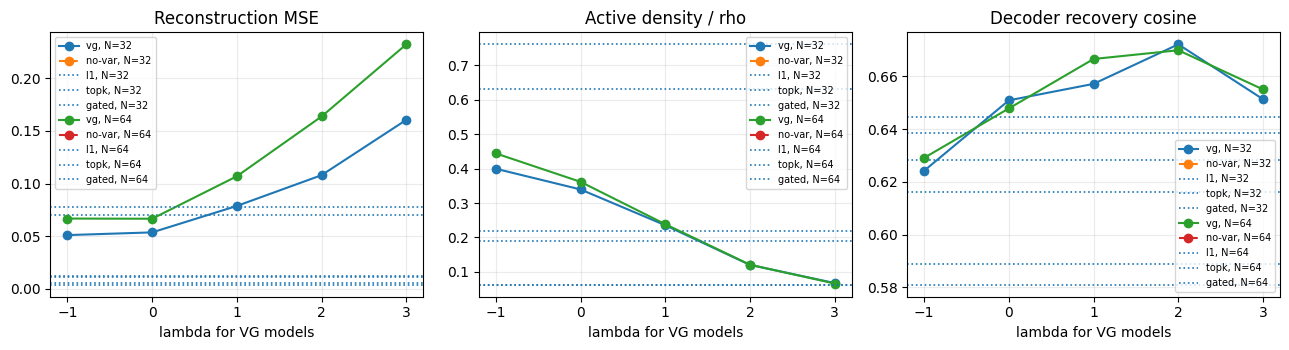

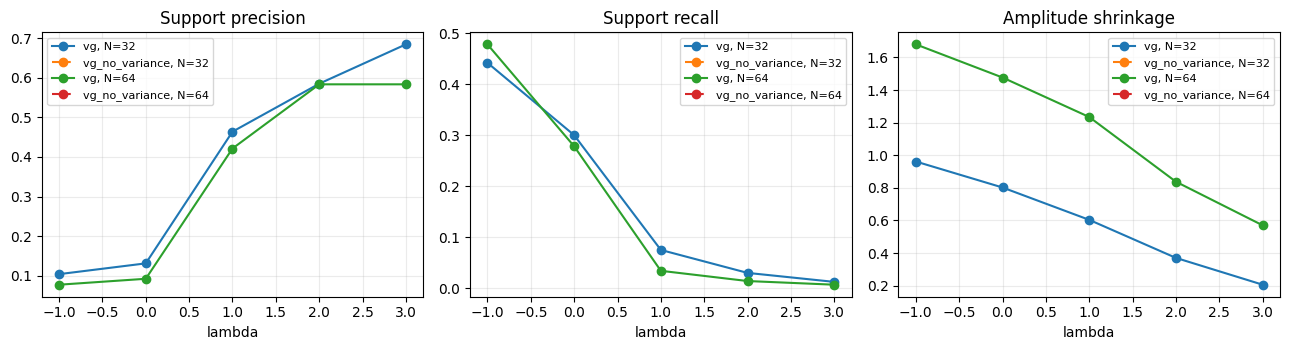

In [7]:
# Baseline vs VG analysis

from IPython.display import display, Markdown

analysis_df = df.copy()

vg_models = ["vg",]
baseline_models = ["l1", "topk", "gated"]

# 1) Compact comparison table: baselines plus best VG rows under a few criteria.
summary_rows = []

for width in sorted(analysis_df["width"].dropna().unique()):
    width_df = analysis_df[analysis_df["width"] == width].copy()

    baselines = width_df[width_df["model"].isin(baseline_models)].copy()
    for _, row in baselines.iterrows():
        summary_rows.append({
            "width": width,
            "selection": "baseline",
            "model": row["model"],
            "lambda": np.nan,
            "mse": row["mse"],
            "rho": row["rho"],
            "decoder_recovery_cosine": row["decoder_recovery_cosine"],
            "support_precision": np.nan,
            "support_recall": np.nan,
            "amplitude_shrinkage": np.nan,
            "variance_energy": np.nan,
        })

    vg_width = width_df[width_df["model"].isin(vg_models)].copy()

    best_mse = vg_width.loc[vg_width["mse"].idxmin()]
    best_recall = vg_width.loc[vg_width["support_recall"].idxmax()]
    best_decoder = vg_width.loc[vg_width["decoder_recovery_cosine"].idxmax()]

    for selection, row in [
        ("best_vg_mse", best_mse),
        ("best_vg_support_recall", best_recall),
        ("best_vg_decoder_recovery", best_decoder),
    ]:
        summary_rows.append({
            "width": width,
            "selection": selection,
            "model": row["model"],
            "lambda": row["lambda"],
            "mse": row["mse"],
            "rho": row["rho"],
            "decoder_recovery_cosine": row["decoder_recovery_cosine"],
            "support_precision": row["support_precision"],
            "support_recall": row["support_recall"],
            "amplitude_shrinkage": row["amplitude_shrinkage"],
            "variance_energy": row["variance_energy"],
        })

comparison = pd.DataFrame(summary_rows).sort_values(["width", "selection", "model"])

display(Markdown("### Baselines vs selected VG checkpoints"))
display(
    comparison.style.format({
        "lambda": "{:.1f}",
        "mse": "{:.4f}",
        "rho": "{:.3f}",
        "decoder_recovery_cosine": "{:.3f}",
        "support_precision": "{:.3f}",
        "support_recall": "{:.3f}",
        "amplitude_shrinkage": "{:.3f}",
        "variance_energy": "{:.3f}",
    })
)

# 2) Plot baseline comparison on metrics available for all models.
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharex=False)

for width in sorted(analysis_df["width"].dropna().unique()):
    width_df = analysis_df[analysis_df["width"] == width].copy()

    vg_sub = width_df[width_df["model"] == "vg"].sort_values("lambda")
    no_var_sub = width_df[width_df["model"] == "vg_no_variance"].sort_values("lambda")
    base_sub = width_df[width_df["model"].isin(baseline_models)].copy()

    axes[0].plot(vg_sub["lambda"], vg_sub["mse"], "-o", label=f"vg, N={width}")
    axes[0].plot(no_var_sub["lambda"], no_var_sub["mse"], "--o", label=f"no-var, N={width}")
    for _, row in base_sub.iterrows():
        axes[0].axhline(row["mse"], linestyle=":", linewidth=1.2, label=f"{row['model']}, N={width}")

    axes[1].plot(vg_sub["lambda"], vg_sub["rho"], "-o", label=f"vg, N={width}")
    axes[1].plot(no_var_sub["lambda"], no_var_sub["rho"], "--o", label=f"no-var, N={width}")
    for _, row in base_sub.iterrows():
        axes[1].axhline(row["rho"], linestyle=":", linewidth=1.2, label=f"{row['model']}, N={width}")

    axes[2].plot(vg_sub["lambda"], vg_sub["decoder_recovery_cosine"], "-o", label=f"vg, N={width}")
    axes[2].plot(no_var_sub["lambda"], no_var_sub["decoder_recovery_cosine"], "--o", label=f"no-var, N={width}")
    for _, row in base_sub.iterrows():
        axes[2].axhline(row["decoder_recovery_cosine"], linestyle=":", linewidth=1.2, label=f"{row['model']}, N={width}")

axes[0].set_title("Reconstruction MSE")
axes[1].set_title("Active density / rho")
axes[2].set_title("Decoder recovery cosine")

for ax in axes:
    ax.set_xlabel("lambda for VG models")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=7)

fig.tight_layout()

# 3) VG-only support analysis, because support precision/recall is defined only for VG-style gates here.
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

for width in sorted(analysis_df["width"].dropna().unique()):
    for model_name, style in [("vg", "-o"), ("vg_no_variance", "--o")]:
        sub = analysis_df[
            (analysis_df["width"] == width)
            & (analysis_df["model"] == model_name)
        ].sort_values("lambda")

        axes[0].plot(sub["lambda"], sub["support_precision"], style, label=f"{model_name}, N={width}")
        axes[1].plot(sub["lambda"], sub["support_recall"], style, label=f"{model_name}, N={width}")
        axes[2].plot(sub["lambda"], sub["amplitude_shrinkage"], style, label=f"{model_name}, N={width}")

axes[0].set_title("Support precision")
axes[1].set_title("Support recall")
axes[2].set_title("Amplitude shrinkage")

for ax in axes:
    ax.set_xlabel("lambda")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

fig.tight_layout()